In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r'Downloads\matches.csv')
data.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
team_name_map = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

for col in ['team1', 'team2', 'winner']:
    data[col] = data[col].replace(team_name_map)



In [4]:
team_name_map

{'Rising Pune Supergiant': 'Rising Pune Supergiants',
 'Delhi Daredevils': 'Delhi Capitals',
 'Deccan Chargers': 'Sunrisers Hyderabad',
 'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'}

# remove the unwanted columns

In [5]:
data.drop(columns=['method'],inplace=True)

# drop none values

In [6]:
data.isnull().sum()
data.dropna(inplace=True)

In [7]:
data.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
umpire1            0
umpire2            0
dtype: int64

# check  duplicatesvalues

In [8]:
data.duplicated().sum()

0

# total matches played

In [9]:
data.shape

(1028, 19)

# 1)in whchi cities ipl has played?

In [10]:
data['city'].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', 'Rajkot', 'Kanpur', 'Bengaluru', 'Dubai', 'Sharjah',
       'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali'], dtype=object)

# 2) participated teams  :

In [11]:
data['team1'].unique()

array(['Royal Challengers Bengaluru', 'Kings XI Punjab', 'Delhi Capitals',
       'Mumbai Indians', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Sunrisers Hyderabad', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Punjab Kings', 'Lucknow Super Giants',
       'Gujarat Titans'], dtype=object)

# 3) Maximum Toss Winner Team :

In [12]:
data['toss_winner'].value_counts().index[0]

'Mumbai Indians'

# 4)most player of the match

In [13]:
data['player_of_match'].value_counts().index[0]

'AB de Villiers'

# Maximum Toss Winner Team :


In [14]:
max_toss_winner=data['toss_winner'].value_counts()


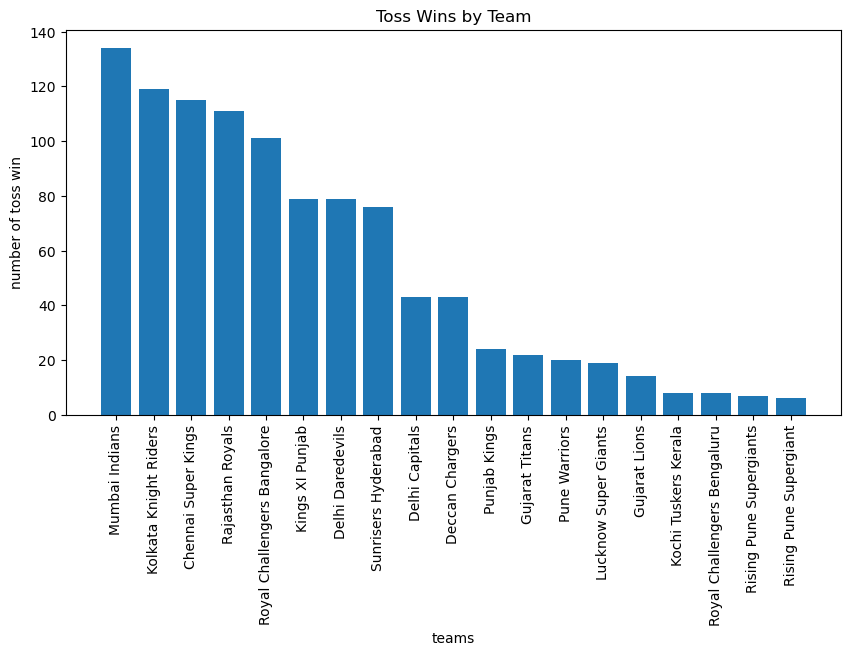

In [15]:
plt.figure(figsize=(10,5))
plt.bar(max_toss_winner.index,max_toss_winner.values)
plt.xlabel('teams')
plt.ylabel('number of toss win')
plt.title('Toss Wins by Team')
plt.xticks(rotation=90)
plt.show()

In [16]:
data['Season'] = pd.to_datetime(data['date']).dt.year  ## extract season from "date" feature

In [17]:
data['Season'] 

0       2008
1       2008
2       2008
3       2008
4       2008
        ... 
1090    2024
1091    2024
1092    2024
1093    2024
1094    2024
Name: Season, Length: 1028, dtype: int64

In [18]:
data.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2,Season
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,2008
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri,2008
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar,2008
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper,2008
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan,2008


In [19]:
data['season']=pd.to_datetime(data['date']).dt.year #extracting the year for seasons

In [20]:
data.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2,Season
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,2008
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri,2008
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar,2008
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper,2008
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan,2008


In [21]:
season_toss_count=data.groupby(['season','toss_decision']).size().reset_index().rename(columns={0:'count'}) #count
# the toss decision according to seasons

In [22]:
season_toss_count.head()

,season,toss_decision,count
0,2008,bat,26
1,2008,field,32
2,2009,bat,35
3,2009,field,21
4,2010,bat,39


# 5) plotting barplot of "Season" vs "count" for bat & field both ..

<Axes: xlabel='season', ylabel='count'>

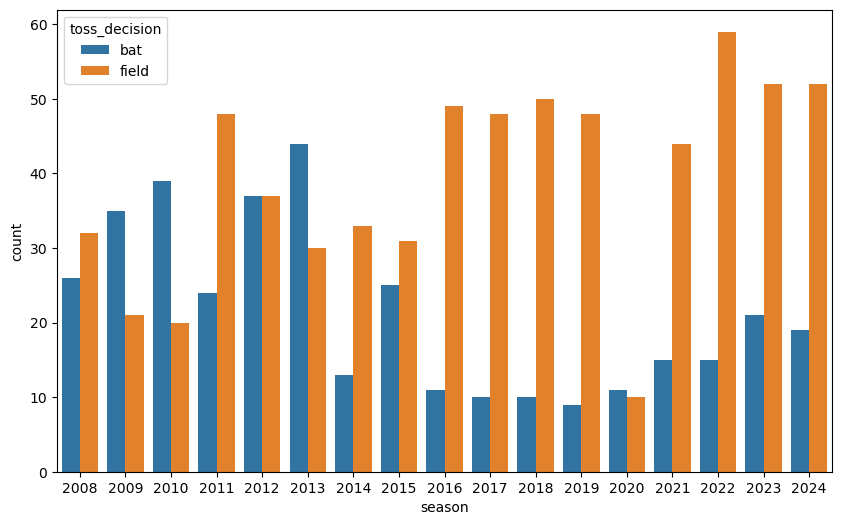

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x='season',y='count',hue='toss_decision',data=season_toss_count)

# 6) winning rate per team

In [24]:
teams_played = pd.concat([data['team1'], data['team2']])
total_matches = teams_played.value_counts()


In [25]:
total_matches

Mumbai Indians                 247
Kolkata Knight Riders          239
Sunrisers Hyderabad            238
Royal Challengers Bengaluru    236
Delhi Capitals                 231
Chennai Super Kings            223
Rajasthan Royals               205
Kings XI Punjab                175
Punjab Kings                    56
Pune Warriors                   45
Gujarat Titans                  45
Lucknow Super Giants            43
Rising Pune Supergiants         30
Gujarat Lions                   29
Kochi Tuskers Kerala            14
dtype: int64

In [26]:
total_matches_win=data['winner'].value_counts()

In [27]:
total_matches_win

Mumbai Indians                 137
Chennai Super Kings            131
Kolkata Knight Riders          127
Royal Challengers Bengaluru    115
Sunrisers Hyderabad            108
Rajasthan Royals               107
Delhi Capitals                 104
Kings XI Punjab                 77
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: winner, dtype: int64

In [28]:
winning_rate=(total_matches_win/total_matches)*100

In [29]:
winning_rate=winning_rate.sort_values(ascending=False)

In [30]:
winning_rate

Gujarat Titans                 62.222222
Chennai Super Kings            58.744395
Lucknow Super Giants           55.813953
Mumbai Indians                 55.465587
Kolkata Knight Riders          53.138075
Rajasthan Royals               52.195122
Rising Pune Supergiants        50.000000
Royal Challengers Bengaluru    48.728814
Sunrisers Hyderabad            45.378151
Delhi Capitals                 45.021645
Gujarat Lions                  44.827586
Kings XI Punjab                44.000000
Kochi Tuskers Kerala           42.857143
Punjab Kings                   42.857143
Pune Warriors                  26.666667
dtype: float64

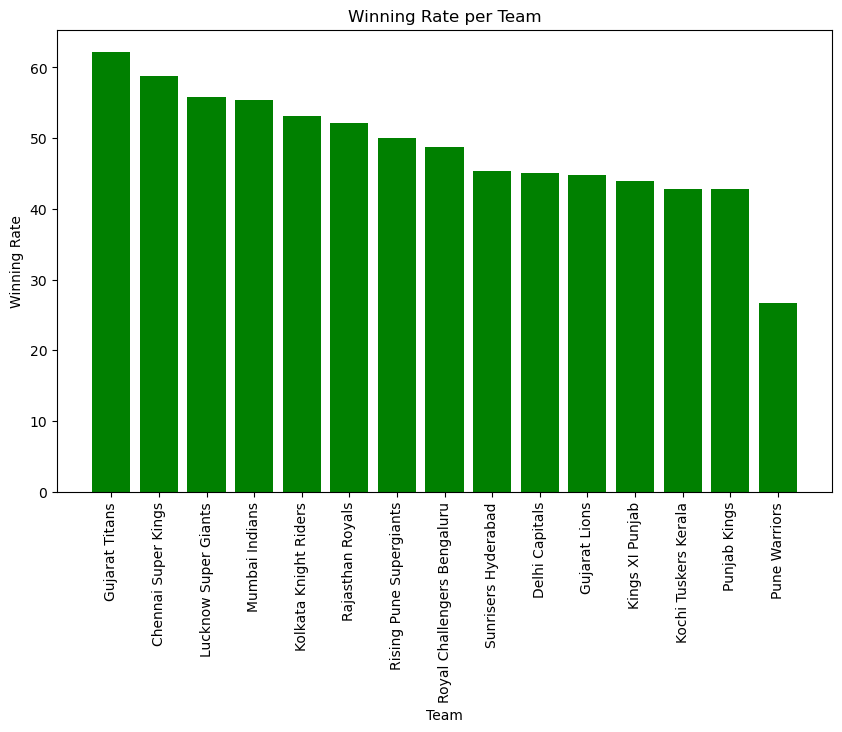

In [31]:
plt.figure(figsize=(10,6))
plt.bar(winning_rate.index, winning_rate.values, color="green")

plt.xlabel('Team')
plt.ylabel('Winning Rate')
plt.title('Winning Rate per Team')
plt.xticks(rotation=90)
plt.show()


# 7) Does Winning toss implies winning game ?

In [32]:
data[['team1', 'team2' , 'toss_winner' , 'winner']]

,team1,team2,toss_winner,winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,Chennai Super Kings
2,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,Delhi Capitals
3,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,Royal Challengers Bengaluru
4,Kolkata Knight Riders,Sunrisers Hyderabad,Deccan Chargers,Kolkata Knight Riders
...,...,...,...,...
1090,Punjab Kings,Sunrisers Hyderabad,Punjab Kings,Sunrisers Hyderabad
1091,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders
1092,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,Rajasthan Royals
1093,Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,Sunrisers Hyderabad


In [33]:
## if "toss_winner" equals to "match_winner" , then assign "Yes" else assign "No"

data['toss_win_game_win'] = np.where(data['toss_winner']==data['winner'] , 'Yes' , 'No')

In [34]:
data['toss_win_game_win'].value_counts()

No     611
Yes    417
Name: toss_win_game_win, dtype: int64

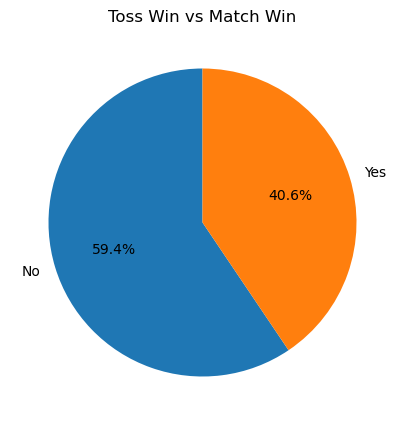

In [35]:
# Pie chart of above values
counts = data['toss_win_game_win'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Toss Win vs Match Win')
plt.show()


# 8) Number of times team have won the tournament :

In [36]:
data['season'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024], dtype=int64)

In [37]:
winners_team ={}

for year in sorted(data['Season'].unique()):
    current_yr_df = data[data['Season']==year]
    winners_team[year] = current_yr_df['winner'].tail(1).values[0]

In [38]:
winners_team

{2008: 'Rajasthan Royals',
 2009: 'Sunrisers Hyderabad',
 2010: 'Chennai Super Kings',
 2011: 'Chennai Super Kings',
 2012: 'Kolkata Knight Riders',
 2013: 'Mumbai Indians',
 2014: 'Kolkata Knight Riders',
 2015: 'Mumbai Indians',
 2016: 'Sunrisers Hyderabad',
 2017: 'Mumbai Indians',
 2018: 'Chennai Super Kings',
 2019: 'Mumbai Indians',
 2020: 'Delhi Capitals',
 2021: 'Chennai Super Kings',
 2022: 'Gujarat Titans',
 2023: 'Chennai Super Kings',
 2024: 'Kolkata Knight Riders'}

In [39]:
from collections import Counter
Counter(winners_team.values())

Counter({'Rajasthan Royals': 1,
         'Sunrisers Hyderabad': 2,
         'Chennai Super Kings': 5,
         'Kolkata Knight Riders': 3,
         'Mumbai Indians': 4,
         'Delhi Capitals': 1,
         'Gujarat Titans': 1})

# 9) Most number of wins :


In [40]:
matches_played = data['team1'].value_counts() + data['team2'].value_counts()

In [41]:
matches_played_df = matches_played.to_frame().reset_index()

In [42]:
matches_played_df.columns = ['team_name' , 'Matches_played']

In [43]:
matches_played_df

,team_name,Matches_played
0,Chennai Super Kings,223
1,Delhi Capitals,231
2,Gujarat Lions,29
3,Gujarat Titans,45
4,Kings XI Punjab,175
5,Kochi Tuskers Kerala,14
6,Kolkata Knight Riders,239
7,Lucknow Super Giants,43
8,Mumbai Indians,247
9,Pune Warriors,45


In [44]:
wins = pd.DataFrame(data['winner'].value_counts()).reset_index()

In [45]:
wins.columns = ['team_name' , 'Wins']

In [46]:
pd.DataFrame(wins)

,team_name,Wins
0,Mumbai Indians,137
1,Chennai Super Kings,131
2,Kolkata Knight Riders,127
3,Royal Challengers Bengaluru,115
4,Sunrisers Hyderabad,108
5,Rajasthan Royals,107
6,Delhi Capitals,104
7,Kings XI Punjab,77
8,Gujarat Titans,28
9,Punjab Kings,24


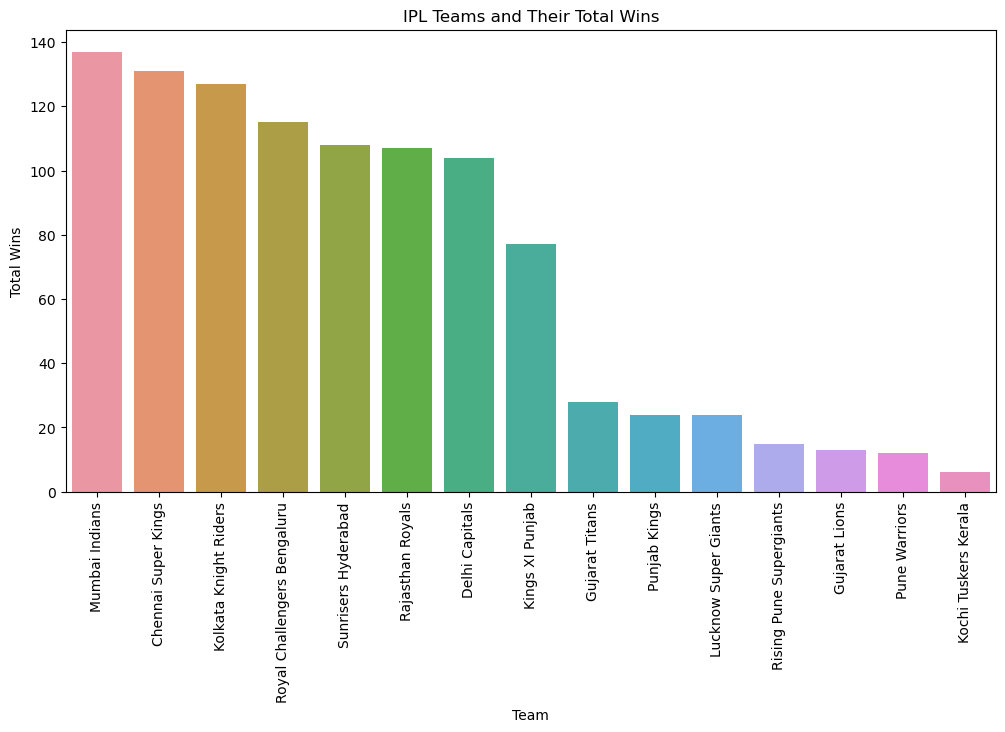

In [47]:
plt.figure(figsize=(12,6))
sns.barplot(x='team_name', y='Wins', data=wins)
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.title('IPL Teams and Their Total Wins')
plt.xticks(rotation=90)
plt.show()


# Particular batsman analysis :
### Lets do in-depth analysis for 'RG Sharma' which is an Indian cricketer !

In [48]:
player=pd.read_csv(r'Downloads/IPL Ball-by-Ball 2008-2024 (1).csv')


In [49]:
player.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [50]:
filt=player['batsman']=="RG Sharma" # filter the particular batsman

In [51]:
df_rohit=player[filt]

In [52]:
df_rohit.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
1070,335986,1,8,2,RG Sharma,A Symonds,M Kartik,0,0,0,0,0,NaN,NaN,NaN,NaN,Deccan Chargers,Kolkata Knight Riders
1071,335986,1,8,3,RG Sharma,A Symonds,M Kartik,0,0,0,0,0,NaN,NaN,NaN,NaN,Deccan Chargers,Kolkata Knight Riders
1072,335986,1,8,4,RG Sharma,A Symonds,M Kartik,0,0,0,0,1,caught,RG Sharma,WP Saha,NaN,Deccan Chargers,Kolkata Knight Riders
1458,335988,1,13,3,RG Sharma,SB Bangar,VY Mahesh,1,0,1,0,0,NaN,NaN,NaN,NaN,Deccan Chargers,Delhi Daredevils
1460,335988,1,13,5,RG Sharma,SB Bangar,VY Mahesh,1,0,1,0,0,NaN,NaN,NaN,NaN,Deccan Chargers,Delhi Daredevils


In [53]:
df_rohit['dismissal_kind'].value_counts()

caught               112
bowled                23
run out               20
lbw                   12
caught and bowled      7
stumped                3
Name: dismissal_kind, dtype: int64

In [54]:
single=len(df_rohit[df_rohit['batsman_runs']==1])# Total runs scored by taking singles ie 1's

In [55]:
double=len(df_rohit[df_rohit['batsman_runs']==2])*2 # Total runs scored by taking singles ie 2's

In [56]:
tripple=len(df_rohit[df_rohit['batsman_runs']==3])*3 # Total runs scored by taking singles ie 3's

In [57]:
fourth=len(df_rohit[df_rohit['batsman_runs']==4])*4 # Total runs scored by taking singles ie 4's

In [58]:
six=len(df_rohit[df_rohit['batsman_runs']==6])*6 # Total runs scored by taking singles ie 6's

In [59]:
labels=['1s','2s','3s','4s','6s']
sizes=[single,double,tripple,fourth,six]

In [60]:
# drawing the donult chart 

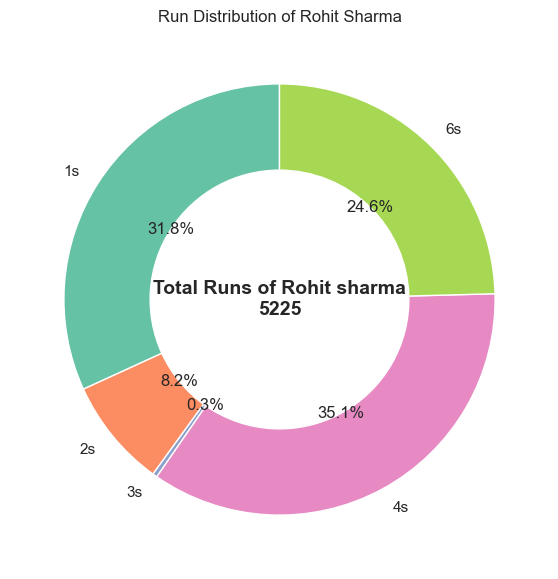

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
colors = sns.color_palette("Set2")

plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.4}
)
total_runs = sum(sizes)
plt.text(0, 0, f"Total Runs of Rohit sharma\n{total_runs}",
         ha='center', va='center',
         fontsize=14, fontweight='bold')
plt.title("Run Distribution of Rohit Sharma")
plt.show()


# Total balls faced by rohit

In [62]:
ball_faced=len(df_rohit)

In [63]:
ball_faced

4088

# rohit strike rate of rohit

In [64]:
strike_rate=(sum(sizes)/ball_faced)*100
print("strike_rate:",strike_rate)

strike_rate: 127.81311154598826


# Particular bowler analysis :¶
### Lets do in-depth analysis for 'JJ bumrah' which is an Indian cricketer !¶

In [65]:
player['bowler'].unique()

array(['AA Noffke', 'Z Khan', 'JH Kallis', 'SB Joshi', 'CL White',
       'P Kumar', 'AB Agarkar', 'SC Ganguly', 'LR Shukla', 'I Sharma',
       'AB Dinda', 'JDP Oram', 'JR Hopes', 'MS Gony', 'K Goel',
       'PP Chawla', 'WA Mota', 'IK Pathan', 'S Sreesanth', 'B Lee',
       'M Muralitharan', 'P Amarnath', 'Joginder Sharma', 'GD McGrath',
       'B Geeves', 'SK Warne', 'YK Pathan', 'D Salunkhe', 'SR Watson',
       'SK Trivedi', 'DL Vettori', 'MF Maharoof', 'MM Patel', 'R Bhatia',
       'B Akhil', 'R Vinay Kumar', 'A Nehra', 'SM Pollock', 'DS Kulkarni',
       'AM Nayar', 'Harbhajan Singh', 'ST Jayasuriya', 'WPUJC Vaas',
       'RP Singh', 'SB Styris', 'SB Bangar', 'DJ Hussey',
       'Mohammad Hafeez', 'M Kartik', 'PP Ojha', 'A Symonds',
       'Pankaj Singh', 'Mohammad Asif', 'VY Mahesh', 'Shahid Afridi',
       'MA Khote', 'DJ Bravo', 'VS Yeligati', 'D Kalyankrishna',
       'VRV Singh', 'A Kumble', 'Sohail Tanvir', 'DNT Zoysa',
       'SD Chitnis', 'Shoaib Malik', 'Yuvraj Singh',

In [66]:
filt2=player['bowler']=='JJ Bumrah'

In [67]:
df_bumrah=player[filt2]

In [68]:
df_bumrah.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
76613,597999,1,4,1,V Kohli,CH Gayle,JJ Bumrah,4,0,4,0,0,NaN,NaN,NaN,NaN,Royal Challengers Bangalore,Mumbai Indians
76614,597999,1,4,2,V Kohli,CH Gayle,JJ Bumrah,4,0,4,0,0,NaN,NaN,NaN,NaN,Royal Challengers Bangalore,Mumbai Indians
76615,597999,1,4,3,V Kohli,CH Gayle,JJ Bumrah,0,0,0,0,0,NaN,NaN,NaN,NaN,Royal Challengers Bangalore,Mumbai Indians
76616,597999,1,4,4,V Kohli,CH Gayle,JJ Bumrah,4,0,4,0,0,NaN,NaN,NaN,NaN,Royal Challengers Bangalore,Mumbai Indians
76617,597999,1,4,5,V Kohli,CH Gayle,JJ Bumrah,0,0,0,0,1,lbw,V Kohli,NaN,NaN,Royal Challengers Bangalore,Mumbai Indians


In [69]:
wicket=df_bumrah['is_wicket'].value_counts()

In [70]:
wicket

0    2040
1     119
Name: is_wicket, dtype: int64

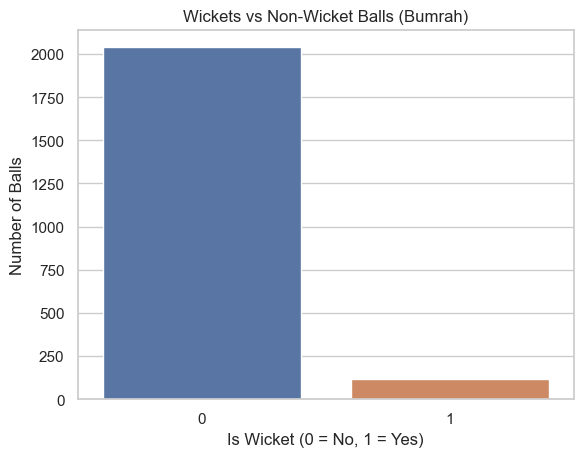

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x=wicket.index,y=wicket)
plt.xlabel("Is Wicket (0 = No, 1 = Yes)")
plt.ylabel("Number of Balls")
plt.title("Wickets vs Non-Wicket Balls (Bumrah)")
plt.show()

# Balls per wicket (bowling strike rate of bumrah)

In [72]:
balls=len(df_bumrah[df_bumrah['extra_runs']==0])
strike_rate=balls/df_bumrah['is_wicket'].sum()
print("strike rate:",strike_rate)

strike rate: 17.159663865546218


# bowling economy rate of bumrah
## (Economy = Total runs  ÷ overs)



In [73]:
total_runs=df_bumrah['total_runs'].sum()
total_runs

2655

In [74]:
overs=balls//6
overs

340

In [75]:
economy=total_runs/overs

In [76]:
print("Bowling economy of bumrah is:",economy)

Bowling economy of bumrah is: 7.8088235294117645


# dot balls percentage

In [77]:
dot_balls=len(df_bumrah[df_bumrah['total_runs']==0])# extracting the dot balls
dot_balls

811

In [78]:
total_balls=balls=len(df_bumrah[df_bumrah['extra_runs']==0]) # calculate total balls

In [79]:
percentage=(dot_balls/total_balls)*100

In [80]:
print("The dot_ball percentage of bumrah:",percentage)

The dot_ball percentage of bumrah: 39.71596474045054
